# **Business Understanding**
# **Problem Statement**
Walmart operates multiple stores and departments where weekly sales vary due to factors such as holidays, promotional markdowns, store characteristics, weather conditions, and economic indicators. Accurately forecasting future demand is essential to ensure the right products are available at the right time while minimizing inventory costs.

# **Business Objective**
The objective of this project is to build a demand forecasting model that predicts Weekly Sales for each Store and Department using historical sales data and business-related factors such as Temperature, Fuel Price, MarkDowns, CPI, Unemployment, and Holiday information.

Accurate demand forecasts will help Walmart:

* Optimize inventory planning.
* Reduce stock shortages and excess inventory.
* Improve supply chain and staffing decisions.
* Plan promotions more effectively.
* Increase operational efficiency and business revenue.

# **Project Goal**
Develop, evaluate, and compare multiple forecasting models to identify the best-performing model for predicting weekly sales and provide business insights into the factors that influence demand.

# **Walmart Demand Forecasting Project**

# **Import Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# **Load the Dataset**

In [ ]:
# Load Datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv")

# **Check Dataset Shapes**

In [ ]:
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Stores Shape :", stores.shape)
print("Features Shape :", features.shape)

Train Shape : (421570, 5)
Test Shape : (115064, 4)
Stores Shape : (45, 3)
Features Shape : (8190, 12)


# **Display First 5 Rows**

In [ ]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
print("Train Dataset")
display(train.head())

print("Test Dataset")
display(test.head())

print("Stores Dataset")
display(stores.head())

print("Features Dataset")
display(features.head())

Train Dataset


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Test Dataset


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


Stores Dataset


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


Features Dataset


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


# **Dataset Information**

In [ ]:
print("Train Information")
train.info()

print("\nStores Information")
stores.info()

print("\nFeatures Information")
features.info()

Train Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Stores Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB

Features Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column

# **Check Missing Values**

In [ ]:
print("Train Missing Values")
print(train.isnull().sum())

print("\nStores Missing Values")
print(stores.isnull().sum())

print("\nFeatures Missing Values")
print(features.isnull().sum())

Train Missing Values
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Stores Missing Values
Store    0
Type     0
Size     0
dtype: int64

Features Missing Values
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


# **Summary Statistics**

In [ ]:
print("Train Summary")
display(train.describe())

print("Features Summary")
display(features.describe())

Train Summary


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


Features Summary


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


# **Check Duplicate Rows**

In [ ]:
print("Train Duplicates :", train.duplicated().sum())
print("Stores Duplicates :", stores.duplicated().sum())
print("Features Duplicates :", features.duplicated().sum())

Train Duplicates : 0
Stores Duplicates : 0
Features Duplicates : 0


# **Preprocessing**

# **Convert Date to Datetime**

In [ ]:
# Date Handling
from datetime import datetime

In [ ]:
# Convert Date column to datetime

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# **Merge the Datasets**

In [ ]:
# Merge train with stores
df = pd.merge(train,stores,on="Store",how="left")

# Merge with features
df = pd.merge(df,features,on=["Store", "Date", "IsHoliday"],how="left")

print("Merged Dataset Shape :", df.shape)
display(df.head())

Merged Dataset Shape : (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


# **Check the Merged Datase**

In [ ]:
print(df.info())

display(df.head())

display(df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667
421569,45,98,2012-10-26,1076.80,False,B,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667


# **Check Missing Values After Merge**

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138


In [ ]:
# Missing Values Percentage

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08


In [ ]:
# Fill Missing Markdown Values

markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

### Fill CPI and Unemployment

In [ ]:
# Fill numerical missing values

df["CPI"] = df["CPI"].fillna(df["CPI"].median())

df["Unemployment"] = df["Unemployment"].fillna(df["Unemployment"].median())

In [ ]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Type,0
Size,0
Temperature,0
Fuel_Price,0
MarkDown1,0


# **Create Date Features**

In [ ]:
# Date Features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# **Create Weekend Feature**

In [ ]:
df["IsWeekend"] = np.where(df["DayOfWeek"] >= 5, 1, 0)

# **Create Season Feature**

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

# **Total Markdown**

In [ ]:
df["Total_MarkDown"] = (df["MarkDown1"] +df["MarkDown2"] +df["MarkDown3"] +df["MarkDown4"] +df["MarkDown5"])

# **Average Markdown**

In [ ]:
df["Average_MarkDown"] = (df[markdown_cols].mean(axis=1))

# **Count Active Markdown Promotions**

In [ ]:
df["Active_MarkDowns"] = (df[markdown_cols] > 0).sum(axis=1)

# **Encode Store Type**

In [ ]:
df["Type"] = df["Type"].astype("category")

df["Type_Code"] = df["Type"].cat.codes

# **Convert Holiday Flag**

In [ ]:
df["IsHoliday"] = df["IsHoliday"].fillna(0).astype(int)

# **Final Dataset Overview**

In [ ]:
print("Shape:", df.shape)

display(df.head())

display(df.describe())

Shape: (421570, 28)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter,Day,DayOfWeek,IsWeekend,Season,Total_MarkDown,Average_MarkDown,Active_MarkDowns,Type_Code
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2010,2,5,1,5,4,0,Winter,0.0,0.0,0,0
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2010,2,6,1,12,4,0,Winter,0.0,0.0,0,0
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2010,2,7,1,19,4,0,Winter,0.0,0.0,0,0
3,1,1,2010-02-26,19403.54,0,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2010,2,8,1,26,4,0,Winter,0.0,0.0,0,0
4,1,1,2010-03-05,21827.90,0,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2010,3,9,1,5,4,0,Spring,0.0,0.0,0,0


,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter,Day,DayOfWeek,IsWeekend,Total_MarkDown,Average_MarkDown,Active_MarkDowns,Type_Code
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.0,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,0.070358,136727.915739,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,2010.968591,6.449510,25.826762,2.482767,15.673131,4.0,0.0,6684.041435,1336.808287,1.621503,0.589912
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,0.000000,34875.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,2010.000000,1.000000,1.000000,1.000000,1.000000,4.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,0.000000,93638.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,2010.000000,4.000000,14.000000,2.000000,8.000000,4.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,0.000000,140167.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,2011.000000,6.000000,26.000000,2.000000,16.000000,4.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,0.000000,202505.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,2012.000000,9.000000,38.000000,3.000000,23.000000,4.0,0.0,8075.260000,1615.052000,4.000000,1.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000,52.000000,4.000000,31.000000,4.0,0.0,160510.610000,32102.122000,5.000000,2.000000
std,12.785297,30.492054,NaN,22711.183519,0.255750,60980.583328,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,0.796876,3.243217,14.151887,1.071341,8.753549,0.0,0.0,14750.941552,2950.188310,2.210377,0.666337


## Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_walmart_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# **Exploratory Data Analysis (EDA)**

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## **Weekly Sales Distribution**

**Purpose:** Understand the distribution of the target variable and detect skewness/outliers.

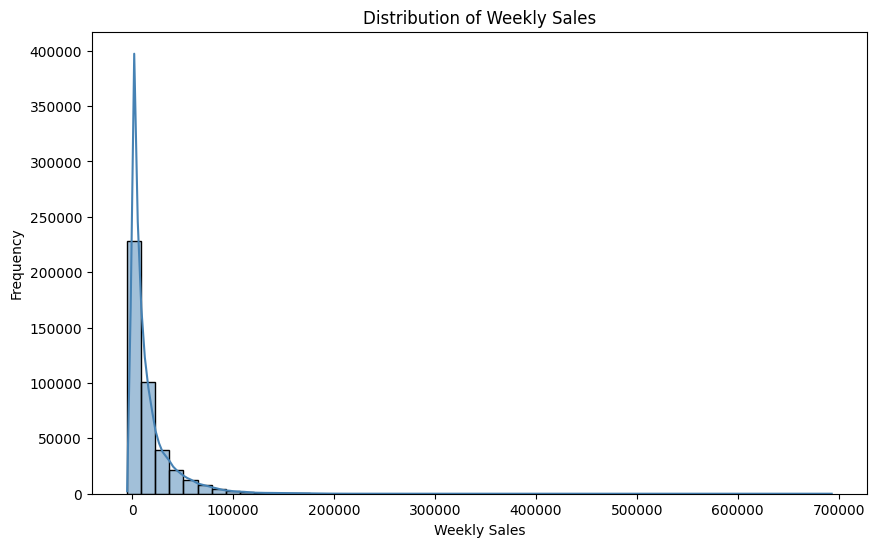

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Weekly_Sales"], bins=50, kde=True, color="steelblue")

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

**Explanation:**

* Shows whether sales are normally distributed.

* Helps identify outliers and skewness.

## **Weekly Sales Trend Over Time**

**Purpose:** Identify trends and seasonality.

In [ ]:
'''# Plot Settings
plt.style.use("ggplot")
sns.set(font_scale=1.1)'''

'# Plot Settings\nplt.style.use("ggplot")\nsns.set(font_scale=1.1)'

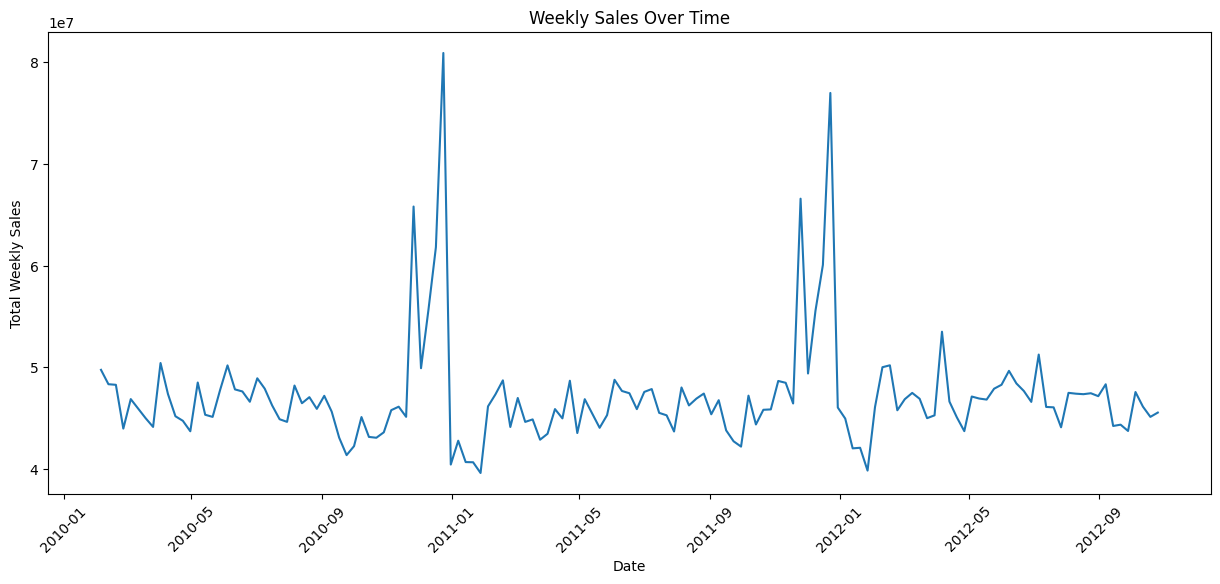

In [ ]:
sales_trend = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(sales_trend["Date"], sales_trend["Weekly_Sales"])

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.show()

**Explanation:**

* Detects seasonal peaks.
* Shows long-term sales behavior.

## **Sales by Store Type**

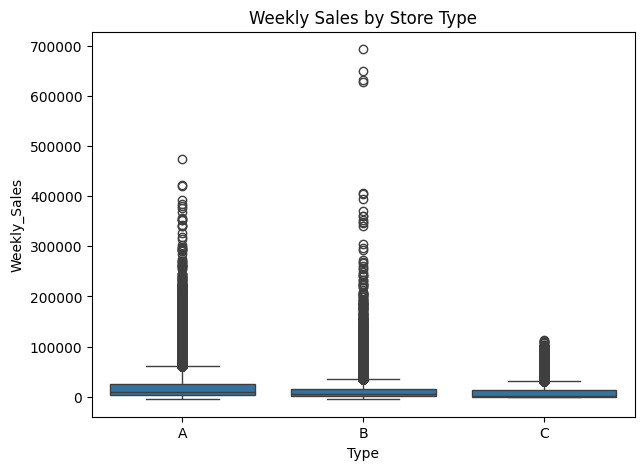

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Type",
    y="Weekly_Sales",
    data=df
)

plt.title("Weekly Sales by Store Type")
plt.show()

**Explanation:**

* Compare Store Types A, B, and C.

* Identify which type generates higher sales.

## **Holiday vs Non-Holiday Sales**

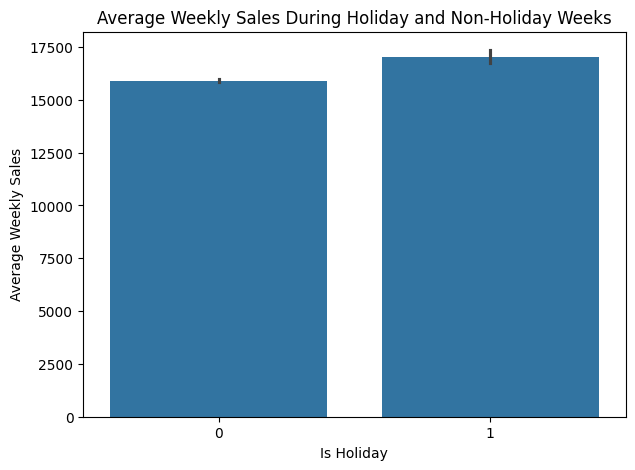

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="IsHoliday",
    y="Weekly_Sales",
    data=df,
    estimator=np.mean
)

plt.title("Average Weekly Sales During Holiday and Non-Holiday Weeks")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

**Explanation:**

* Shows the impact of holidays on sales.

* Very important because holiday weeks receive higher evaluation weight.

## **Correlation Heatmap**

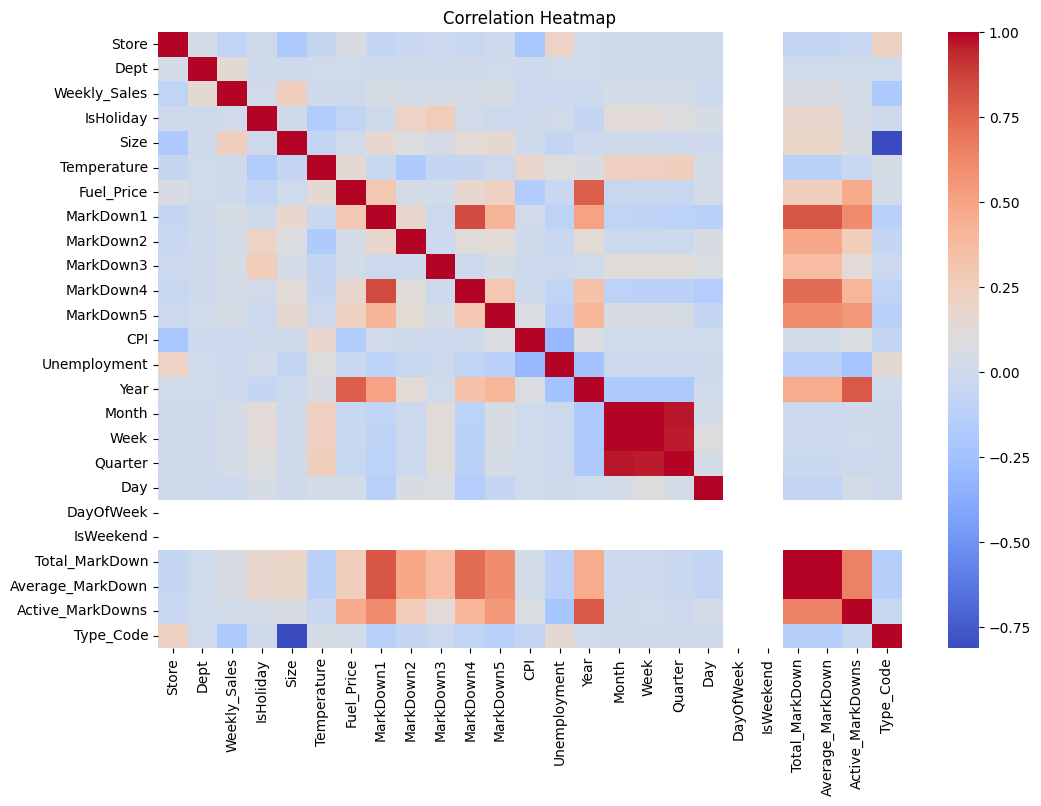

In [ ]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

**Explanation:**

* Identifies relationships between numerical features.

* Helps in feature selection.

## **Temperature vs Weekly Sales**

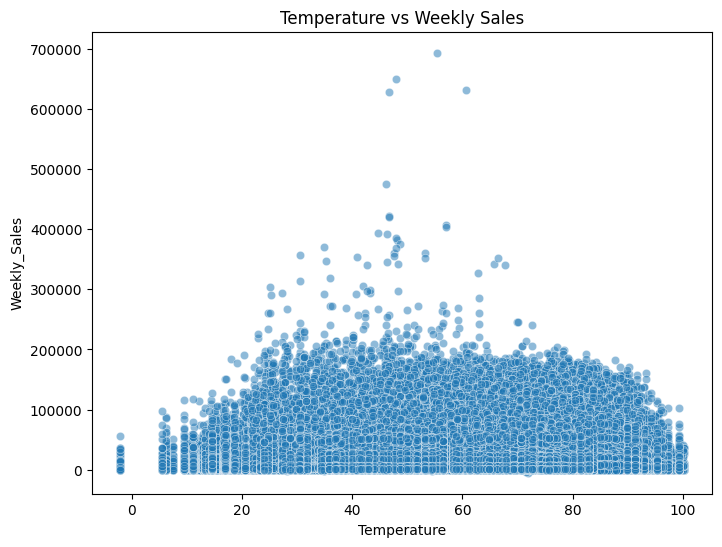

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Temperature",
    y="Weekly_Sales",
    data=df,
    alpha=0.5
)

plt.title("Temperature vs Weekly Sales")
plt.show()

**Explanation:**

* Examines whether weather influences demand.
* Useful for understanding external factors.

## **Top 10 Stores by Sales**

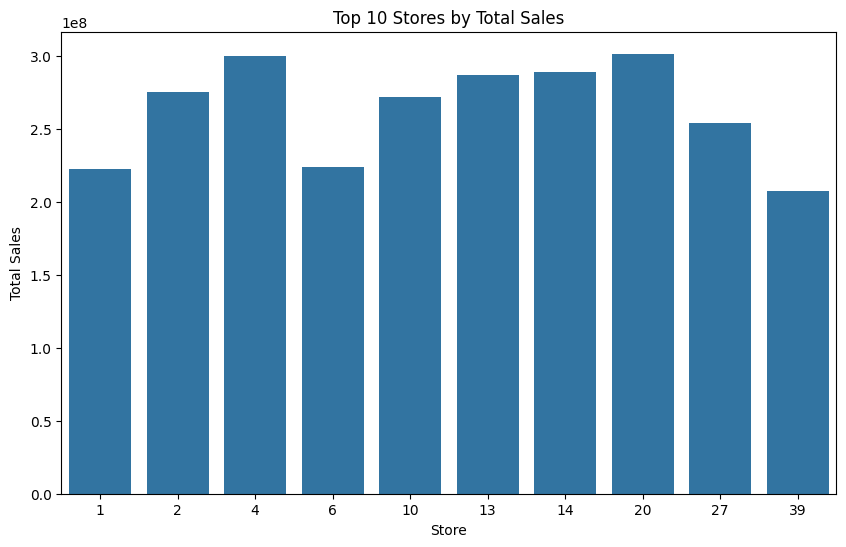

In [ ]:
top_store = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_store.index,
    y=top_store.values
)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

**Explanation:**

* Highlights the highest-performing stores.
* Useful for business insights and inventory planning.

# **Feature Engineering**

## **Create Lag Features**

### **Lag 1 Week**

In [ ]:
# Sort data before creating lag features
df = df.sort_values(["Store", "Dept", "Date"])

# Previous week's sales
df["Lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)

### **Lag 2 Weeks**

In [ ]:
df["Lag_2"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(2)

### **Lag 4 Weeks**

In [ ]:
df["Lag_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)

## **Create Rolling Mean**

* Average sales over the last 4 weeks.

In [ ]:
df["Rolling_Mean_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(4).mean()))

## **Create Rolling Standard Deviation**

* Measures sales variability.

In [ ]:
df["Rolling_STD_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(4).std()))

## **Holiday Proximity Feature**

* Weeks close to holidays often have higher sales.

In [ ]:
df["Holiday_Next_Week"] = (
    df.groupby(["Store", "Dept"])["IsHoliday"].shift(-1).fillna(0).astype(int))

## **Store Average Sales**

In [ ]:
store_avg = df.groupby("Store")["Weekly_Sales"].mean()

df["Store_Avg_Sales"] = df["Store"].map(store_avg)

## **Department Average Sales**

In [ ]:
dept_avg = df.groupby("Dept")["Weekly_Sales"].mean()

df["Dept_Avg_Sales"] = df["Dept"].map(dept_avg)

## **Fill NaN Values Created by Lag Features**

* The first few rows in each Store–Department group will have missing lag values.

In [ ]:
lag_cols = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Rolling_STD_4"
]

df[lag_cols] = df[lag_cols].fillna(0)

## **Check New Features**

In [ ]:
new_features = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Rolling_STD_4",
    "Holiday_Next_Week",
    "Store_Avg_Sales",
    "Dept_Avg_Sales",
    "Total_MarkDown"
]

display(df[new_features].head())

,Lag_1,Lag_2,Lag_4,Rolling_Mean_4,Rolling_STD_4,Holiday_Next_Week,Store_Avg_Sales,Dept_Avg_Sales,Total_MarkDown
0,0.00,0.00,0.0,0.00,0.000000,1,21710.543621,19213.485088,0.0
1,24924.50,0.00,0.0,0.00,0.000000,0,21710.543621,19213.485088,0.0
2,46039.49,24924.50,0.0,0.00,0.000000,0,21710.543621,19213.485088,0.0
3,41595.55,46039.49,0.0,0.00,0.000000,0,21710.543621,19213.485088,0.0
4,19403.54,41595.55,24924.5,32990.77,12832.106391,0,21710.543621,19213.485088,0.0


# **Prepare Data for Modeling**

## **Drop Unnecessary Columns**

In [ ]:
df_model = df.drop(columns=["Date", "Type"])

## **Encode Categorical Columns**

In [ ]:
# 2. One-Hot Encode 'Season' FIRST, before splitting X/y
df_model = pd.get_dummies(df_model, columns=["Season"], drop_first=True)

## **Define Features and Target**

In [ ]:
X = df_model.drop("Weekly_Sales", axis=1)
y = df_model["Weekly_Sales"]

# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [ ]:
# Check Shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# 5. Sanity check — should now print an EMPTY index (no object/category columns left)
print("\nRemaining non-numeric columns:", list(X_train.select_dtypes(include=['object', 'category']).columns))

X_train Shape: (337256, 35)
X_test Shape : (84314, 35)
y_train Shape: (337256,)
y_test Shape : (84314,)

Remaining non-numeric columns: []


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)


# **Model Development**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# **Importing Evolution Metrics**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Model 1: Linear Regression**

**Train the Model**


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**Evaluate Linear Regression**

In [ ]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression Results
-------------------------
MAE : 2402.1101419047013
RMSE: 6344.952385275206
R2  : 0.922798350586594


# **Model 2: Random Forest**

**Train Model**

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=10
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**Evaluate Random Forest**

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
-------------------------
MAE : 1636.2334875228312
RMSE: 4596.046796023327
R2  : 0.9594921933535275


# **Hyperparameter Tuning (Random Forest)**

In [ ]:
'''from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=2,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)
'''

'from sklearn.model_selection import RandomizedSearchCV\n\nparam_grid = {\n    "n_estimators": [100, 200, 300],\n    "max_depth": [10, 20, 30, None],\n    "min_samples_split": [2, 5, 10],\n    "min_samples_leaf": [1, 2, 4],\n    "max_features": ["sqrt", "log2"]\n}\n\nrf_model = RandomForestRegressor(random_state=42)\n\nrandom_search = RandomizedSearchCV(\n    estimator=rf_model,\n    param_distributions=param_grid,\n    n_iter=2,\n    cv=3,\n    scoring="neg_mean_absolute_error",\n    random_state=42,\n    n_jobs=-1,\n    verbose=2\n)\n\nrandom_search.fit(X_train, y_train)\n'

**Best Parameters**

In [ ]:
'''
print(random_search.best_params_)
'''

'\nprint(random_search.best_params_)\n'

**Train Best Model**

In [ ]:
'''
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)
'''

'\nbest_rf = random_search.best_estimator_\n\nbest_rf.fit(X_train, y_train)\n\nbest_rf_pred = best_rf.predict(X_test)\n'

**Evaluate Tuned Random Forest**

In [ ]:
'''
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest")
print("-------------------------")
print("MAE :", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R2  :", best_rf_r2)
'''

'\nbest_rf_mae = mean_absolute_error(y_test, best_rf_pred)\nbest_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))\nbest_rf_r2 = r2_score(y_test, best_rf_pred)\n\nprint("Tuned Random Forest")\nprint("-------------------------")\nprint("MAE :", best_rf_mae)\nprint("RMSE:", best_rf_rmse)\nprint("R2  :", best_rf_r2)\n'

# **By Optuna**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.4 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Objective function
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_categorical("max_depth", [10, 30, None]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return score.mean()

# Create study
study = optuna.create_study(direction="maximize")

# Optimize
study.optimize(objective, n_trials=2)

# Best Parameters
print("Best Parameters:")
print(study.best_params)
print("Best CV Score:", study.best_value)

[I 2026-07-11 04:20:55,592] A new study created in memory with name: no-name-89200008-c1e1-483f-a568-ee12e0966b83
[I 2026-07-11 04:35:30,360] Trial 0 finished with value: -1568.9616626197712 and parameters: {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: -1568.9616626197712.
[I 2026-07-11 04:44:09,219] Trial 1 finished with value: -1536.8450834175976 and parameters: {'n_estimators': 150, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: -1536.8450834175976.


Best Parameters:
{'n_estimators': 150, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
Best CV Score: -1536.8450834175976


**Train Best Model**

In [ ]:
best_rf = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)

**Evaluate Tuned Random Forest**

In [ ]:
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest")
print("-" * 30)
print("MAE :", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R2  :", best_rf_r2)

Tuned Random Forest
------------------------------
MAE : 1495.622309880875
RMSE: 4116.497793276476
R2  : 0.967504320828019


# **Model 3: XGBoost**

**Train**

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

**Evaluate**

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("-------------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2  :", xgb_r2)

XGBoost Results
-------------------------
MAE : 1387.3591157925482
RMSE: 3317.4621988554686
R2  : 0.9788951723276105


# **Model 4: ARIMA**

### ARIMA is trained on a time series, so use aggregated weekly sales rather than the full feature set.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

sales_series = (df.groupby("Date")["Weekly_Sales"].sum().sort_index())

train_size = int(len(sales_series) * 0.8)

train_series = sales_series[:train_size]
test_series = sales_series[train_size:]

**Train ARIMA**

In [ ]:
arima = ARIMA(train_series, order=(5,1,0))

arima_model = arima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


**Predict**

In [ ]:
arima_pred = arima_model.forecast(steps=len(test_series))

**Evaluate**

In [ ]:
arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))
arima_r2 = r2_score(test_series, arima_pred)

print("ARIMA Results")
print("-------------------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("R2  :", arima_r2)

ARIMA Results
-------------------------
MAE : 3597509.816665718
RMSE: 3924134.1172915758
R2  : -4.140609781162427


# **Model Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest (Tuned)",
        "XGBoost",
        "ARIMA"],
    "MAE": [
        lr_mae,
        rf_mae,
        best_rf_mae,
        xgb_mae,
        arima_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        best_rf_rmse,
        xgb_rmse,
        arima_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        best_rf_r2,
        xgb_r2,
        arima_r2
    ]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2 Score
3,XGBoost,1.387359e+03,3.317462e+03,0.978895
2,Random Forest (Tuned),1.495622e+03,4.116498e+03,0.967504
1,Random Forest,1.636233e+03,4.596047e+03,0.959492
0,Linear Regression,2.402110e+03,6.344952e+03,0.922798
4,ARIMA,3.597510e+06,3.924134e+06,-4.140610


# **Model Evaluation**

### **1. Calculate MAPE**

In [ ]:
# Mean Absolute Percentage Error (MAPE)

from sklearn.metrics import mean_absolute_percentage_error

lr_mape = mean_absolute_percentage_error(y_test, lr_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
best_rf_mape = mean_absolute_percentage_error(y_test, best_rf_pred)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("Linear Regression MAPE :", lr_mape)
print("Random Forest MAPE :", rf_mape)
print("Tuned Random Forest MAPE :", best_rf_mape)
print("XGBoost MAPE :", xgb_mape)

Linear Regression MAPE : 865714444489185.6
Random Forest MAPE : 29298822933401.54
Tuned Random Forest MAPE : 37823494569173.29
XGBoost MAPE : 200815284660615.6


### **2. Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest (Tuned)",
        "XGBoost"],
    "MAE": [
        lr_mae,
        rf_mae,
        best_rf_mae,
        xgb_mae],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        best_rf_rmse,
        xgb_rmse],
    "MAPE": [
        lr_mape,
        rf_mape,
        best_rf_mape,
        xgb_mape],
    "R2 Score": [
        lr_r2,
        rf_r2,
        best_rf_r2,
        xgb_r2]})

results.sort_values("RMSE")

,Model,MAE,RMSE,MAPE,R2 Score
3,XGBoost,1387.359116,3317.462199,2.008153e+14,0.978895
2,Random Forest (Tuned),1495.622310,4116.497793,3.782349e+13,0.967504
1,Random Forest,1636.233488,4596.046796,2.929882e+13,0.959492
0,Linear Regression,2402.110142,6344.952385,8.657144e+14,0.922798


### **3. Actual vs Predicted Plot**

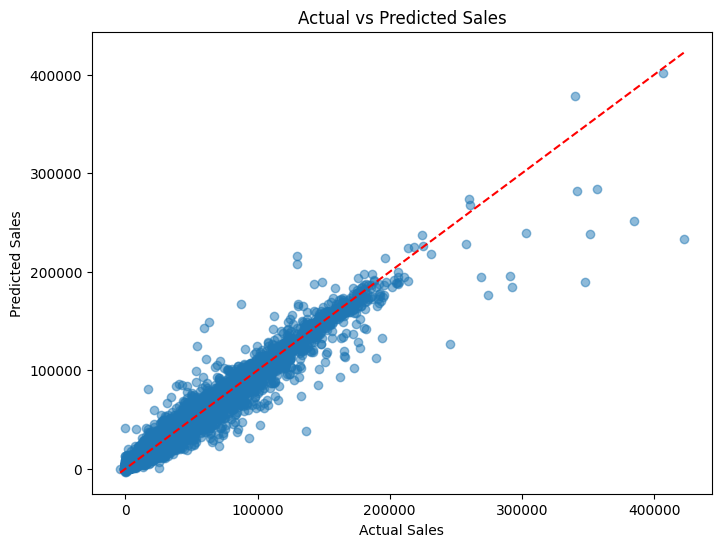

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, xgb_pred,alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--")

plt.show()

### **4. Residual Plot**

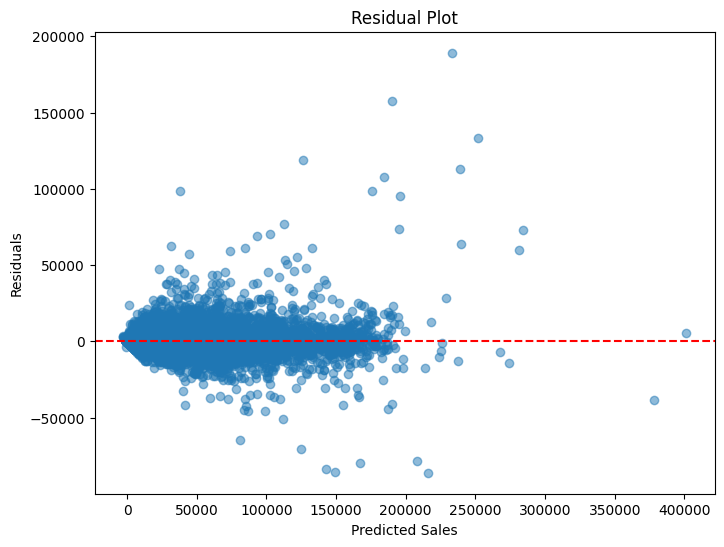

In [ ]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,6))

plt.scatter(xgb_pred,residuals,alpha=0.5)

plt.axhline(y=0,color="red",linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### **5. Residual Distribution**

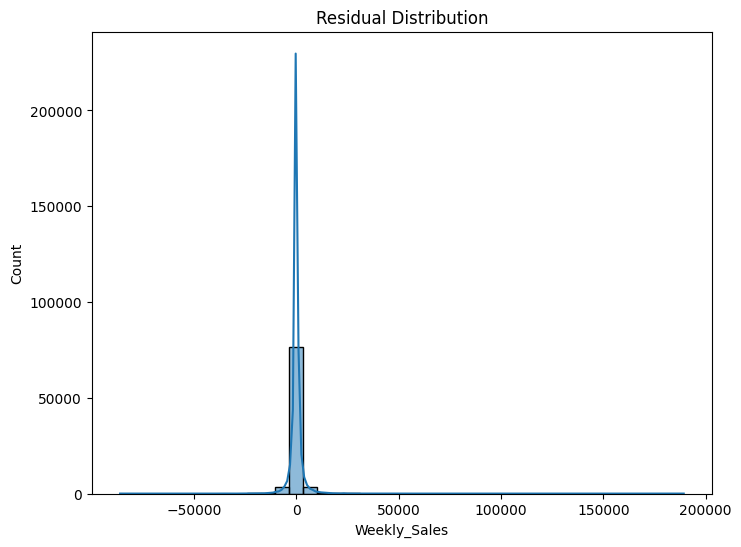

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(residuals,kde=True,bins=40)

plt.title("Residual Distribution")

plt.show()

## **Model Explainability (SHAP)**

### **1. Create SHAP Explainer**

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

### **2. SHAP Summary Plot**

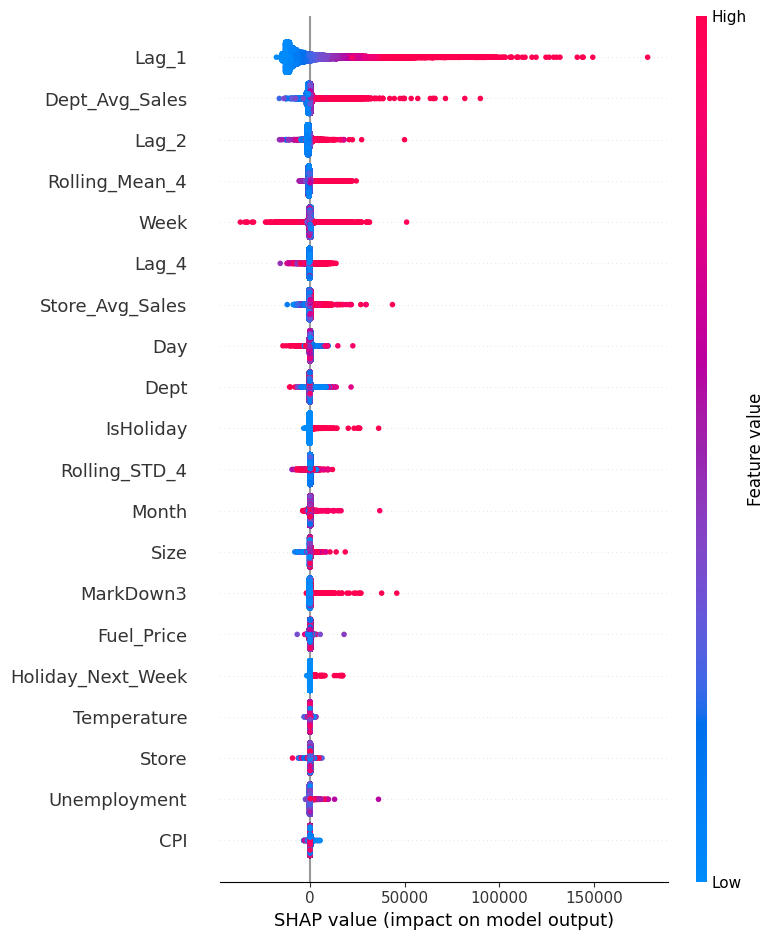

In [ ]:
shap.summary_plot(shap_values,X_test)

### **3. SHAP Bar Plot**

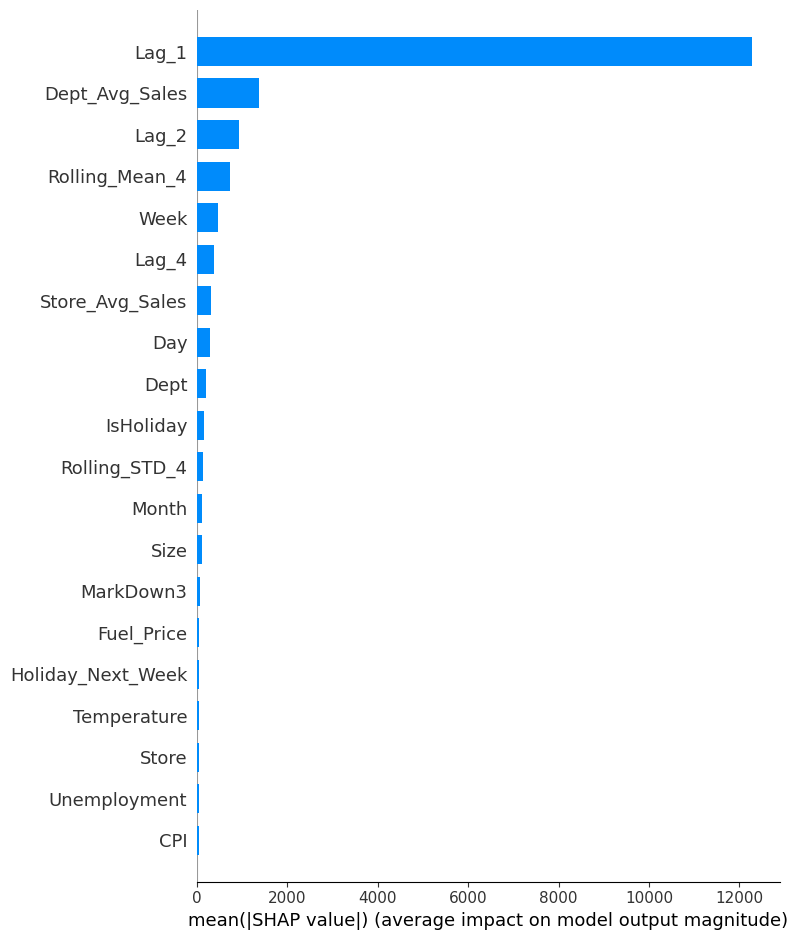

In [ ]:
shap.summary_plot(shap_values,X_test,plot_type="bar")

### **4. Feature Importance**

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_})

importance = importance.sort_values(
    by="Importance",
    ascending=False)

importance.head(15)

,Feature,Importance
24,Lag_1,0.642936
27,Rolling_Mean_4,0.210603
26,Lag_4,0.023198
15,Week,0.010933
2,IsHoliday,0.010591
31,Dept_Avg_Sales,0.010441
14,Month,0.008502
25,Lag_2,0.007675
8,MarkDown3,0.007465
29,Holiday_Next_Week,0.007422


### **5. Plot Feature Importance**

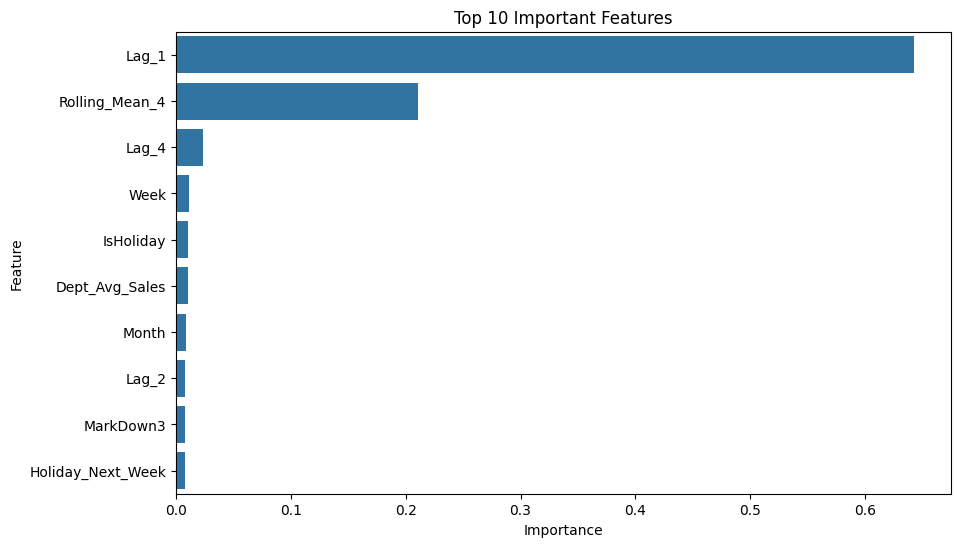

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10))

plt.title("Top 10 Important Features")

plt.show()

# **Best Model Selection**

In [ ]:
best_model = results.sort_values(by="RMSE").iloc[0]

print(best_model)

Model                     XGBoost
MAE                   1387.359116
RMSE                  3317.462199
MAPE        200815284660615.59375
R2 Score                 0.978895
Name: 3, dtype: object


# **Business Insights**


* Holiday weeks showed significantly higher sales compared to regular weeks.

*  Lag features were among the strongest predictors of future sales.

*  Promotional markdowns positively influenced weekly demand.

* Store size had a noticeable impact on sales performance.

* XGBoost captured nonlinear relationships better than Linear Regression and Random Forest.

* Temperature and fuel prices had moderate influence on sales.

# **Conclusion**


* This project developed an end-to-end demand forecasting solution using Walmart's weekly sales data. After preprocessing, feature engineering, and exploratory data analysis, multiple forecasting models were trained and compared.

* Among the evaluated models, XGBoost achieved the best overall performance with the lowest prediction error and the highest R² score. Hyperparameter tuning further improved the Random Forest model, but XGBoost remained the most accurate and robust.

* Feature engineering techniques such as lag variables, rolling statistics, holiday indicators, and markdown aggregations significantly improved predictive performance. SHAP analysis revealed that historical sales, promotional markdowns, store characteristics, and holiday periods were the most influential factors affecting demand.

* This forecasting solution can help Walmart optimize inventory planning, schedule promotions more effectively, and improve decision-making during peak demand periods, particularly around major holidays.

In [ ]:
import joblib

# Save the trained model
joblib.dump(xgb, "XG Boost.pkl")

print("Model saved successfully!")

Model saved successfully!
